# Low-Rank vs Full GRF Kernel

In [7]:
num_nodes = 20
max_walk_length = 4
proj_dims = [1, 2, 4, 6, 8, 10, 12, 16, 20]
jlt_seed = 0
modulation = [1.0, 0.6, -0.3, 0.15]

In [8]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

root = Path.cwd()
if not (root / "src").exists():
    root = root.parent
sys.path.insert(0, str(root / "src"))

from grf_gp.kernels.general import GeneralGRFKernel, GeneralLowRankGRFKernel

In [9]:
adjacency = torch.zeros(num_nodes, num_nodes)
for i in range(num_nodes - 1):
    adjacency[i, i + 1] = 1.0
    adjacency[i + 1, i] = 1.0
adjacency += torch.eye(num_nodes)
transition = adjacency / adjacency.sum(dim=1, keepdim=True)
rw_mats = [torch.linalg.matrix_power(transition, t) for t in range(max_walk_length)]
modulation = torch.tensor(modulation)

full_kernel = GeneralGRFKernel(rw_mats=rw_mats, max_walk_length=max_walk_length)
with torch.no_grad():
    full_kernel.raw_modulation_function.copy_(modulation)

full_gram = full_kernel.forward()

approx_grams = {}
errors = []

for proj_dim in proj_dims:
    kernel = GeneralLowRankGRFKernel(
        rw_mats=rw_mats,
        max_walk_length=max_walk_length,
        proj_dim=proj_dim,
        jlt_seed=jlt_seed,
    )
    with torch.no_grad():
        kernel.raw_modulation_function.copy_(modulation)

    gram = kernel.forward()
    diff = gram - full_gram
    approx_grams[proj_dim] = gram
    errors.append(torch.linalg.norm(diff).item())

/var/folders/0v/vn4885796ql7_mlpq_dc1n9r0000gn/T/ipykernel_44417/655621558.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


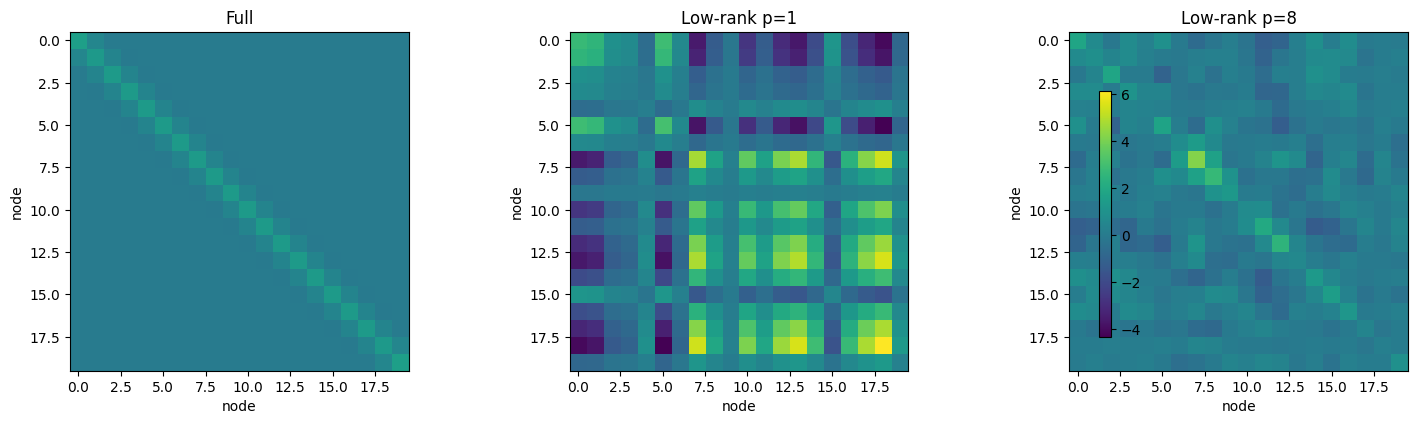

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

selected_proj_dims = [proj_dims[0], proj_dims[len(proj_dims) // 2], proj_dims[-1]]
vmin = min(full_gram.min().item(), *(approx_grams[p].min().item() for p in selected_proj_dims))
vmax = max(full_gram.max().item(), *(approx_grams[p].max().item() for p in selected_proj_dims))

images = []
images.append(axes[0].imshow(full_gram.detach().cpu(), cmap="viridis", vmin=vmin, vmax=vmax))
axes[0].set_title("Full")

for ax, proj_dim in zip(axes[1:], selected_proj_dims[:2]):
    images.append(ax.imshow(approx_grams[proj_dim].detach().cpu(), cmap="viridis", vmin=vmin, vmax=vmax))
    ax.set_title(f"Low-rank p={proj_dim}")

for ax in axes:
    ax.set_xlabel("node")
    ax.set_ylabel("node")

fig.colorbar(images[0], ax=axes, shrink=0.8)
plt.tight_layout()

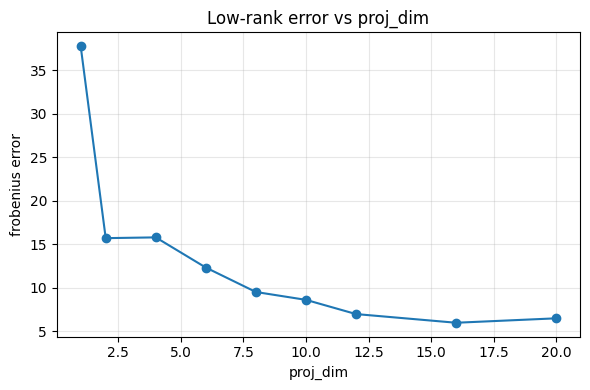

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(proj_dims, errors, marker="o")
plt.xlabel("proj_dim")
plt.ylabel("frobenius error")
plt.title("Low-rank error vs proj_dim")
plt.grid(True, alpha=0.3)
plt.tight_layout()